In [1]:
import sys
!{sys.executable} -m pip install pymysql

## Imports

In [1]:
import pandas as pd 
import numpy as np
from sqlalchemy import create_engine
import pymysql
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

### DataBase Connection

In [2]:
username = "Username"
password = "Password"

host = "localhost"
port = 3306
database = "super_store"

encoded_password = quote_plus(password)

engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}")

In [3]:
# connection test 
connection = engine.connect()

print("Connection successful!")

Connection successful!


In [4]:
connection.close()

In [5]:
query = """
    SELECT
    f.OrderID,
    f.OrderDate,
    f.ShipDate,
    f.Sales,
    f.Quantity,
    f.Discount,

    g.City,
    g.Country,
    g.Market,
    g.Region,
    g.State,

    op.OrderPriority,

    c.Segment,

    p.Category,
    p.SubCategory,
    p.ProductName,

    sm.ShipMode,

    f.Profit

FROM factsales AS f

LEFT JOIN dimgeography AS g
    ON f.GeoKey = g.GeoKey

LEFT JOIN dimorderpriority AS op
    ON f.PriorityKey = op.PriorityKey

LEFT JOIN dimcustomer AS c
    ON f.CustomerID = c.CustomerID

LEFT JOIN dimproduct AS p
    ON f.ProductID = p.ProductID

LEFT JOIN dimshipmode AS sm
    ON f.ShipModeID = sm.ShipModeID;
    """

In [6]:
df = pd.read_sql(query, engine)

In [8]:
df.head(10)

,OrderID,OrderDate,ShipDate,Sales,Quantity,Discount,City,Country,Market,Region,State,OrderPriority,Segment,Category,SubCategory,ProductName,ShipMode,Profit
0,MX-2014-143658,2014-10-02,2014-10-06,13.080,3,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Standard Class,4.560
1,MX-2013-119970,2013-06-25,2013-07-01,263.920,2,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Office Supplies,Storage,"Eldon Lockers, Single Width",Standard Class,5.240
2,MX-2014-100727,2014-05-15,2014-05-18,300.720,14,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Fiskars Box Cutter, Serrated",First Class,129.080
3,MX-2014-100727,2014-05-15,2014-05-18,138.180,7,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Acme Letter Opener, Steel",First Class,53.760
4,MX-2014-100727,2014-05-15,2014-05-18,90.800,4,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Kleencut Box Cutter, Steel",First Class,31.760
5,MX-2013-119970,2013-06-25,2013-07-01,144.300,5,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Office Supplies,Supplies,"Elite Trimmer, Easy Grip",Standard Class,36.000
6,MX-2012-141915,2012-10-10,2012-10-16,266.544,9,0.2,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Furniture,Chairs,"Office Star Bag Chairs, Red",Standard Class,6.624
7,MX-2014-135265,2014-12-25,2014-12-31,47.400,3,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Corporate,Office Supplies,Paper,"Green Bar Message Books, Recycled",Standard Class,22.260
8,MX-2012-129623,2012-05-24,2012-05-28,63.648,3,0.4,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Furniture,Furnishings,"Advantus Photo Frame, Duo Pack",Standard Class,8.448
9,MX-2012-168865,2012-09-14,2012-09-19,38.400,2,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Binders,"Cardinal 3-Hole Punch, Economy",Standard Class,11.520


In [9]:
df.shape

(46690, 18)

### EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46690 entries, 0 to 46689
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        46690 non-null  object        
 1   OrderDate      46690 non-null  datetime64[ns]
 2   ShipDate       46690 non-null  datetime64[ns]
 3   Sales          46690 non-null  float64       
 4   Quantity       46690 non-null  int64         
 5   Discount       46690 non-null  float64       
 6   City           46690 non-null  object        
 7   Country        46690 non-null  object        
 8   Market         46690 non-null  object        
 9   Region         46690 non-null  object        
 10  State          46690 non-null  object        
 11  OrderPriority  46690 non-null  object        
 12  Segment        46690 non-null  object        
 13  Category       46690 non-null  object        
 14  SubCategory    46690 non-null  object        
 15  ProductName    4669

In [11]:
df.isnull().sum()

OrderID          0
OrderDate        0
ShipDate         0
Sales            0
Quantity         0
Discount         0
City             0
Country          0
Market           0
Region           0
State            0
OrderPriority    0
Segment          0
Category         0
SubCategory      0
ProductName      0
ShipMode         0
Profit           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(9)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(46681, 18)

Finding the difference between OrderDate & ShipDate

In [15]:
df['Diff b/w order and ship date'] = df['ShipDate'] - df['OrderDate']

In [16]:
df['Diff b/w order and ship date'].value_counts()

Diff b/w order and ship date
4 days    13197
5 days    10266
2 days     6339
6 days     5719
3 days     4562
7 days     2758
0 days     2353
1 days     1487
Name: count, dtype: int64

In [17]:
df['Diff b/w order and ship date']=df['Diff b/w order and ship date'].dt.days
#dropping 'days' word from the values

In [18]:
df['Diff b/w order and ship date'].value_counts()

Diff b/w order and ship date
4    13197
5    10266
2     6339
6     5719
3     4562
7     2758
0     2353
1     1487
Name: count, dtype: int64

In [ ]:
#Converting 'OrderDate' and 'ShipDate' columns to [day,month,year] columns

In [19]:
df['Order Month'] = df['OrderDate'].dt.month   # Seasonality 
df['Order Year'] = df['OrderDate'].dt.year
df['Order Day of Week'] = df['OrderDate'].dt.dayofweek

In [20]:
df['Order Month'] = df['ShipDate'].dt.month   
df['Order Year'] = df['ShipDate'].dt.year
df['Order Day of Week'] = df['ShipDate'].dt.dayofweek

In [21]:
df.drop(['OrderDate','ShipDate'],axis=1,inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46681 entries, 0 to 46689
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OrderID                       46681 non-null  object 
 1   Sales                         46681 non-null  float64
 2   Quantity                      46681 non-null  int64  
 3   Discount                      46681 non-null  float64
 4   City                          46681 non-null  object 
 5   Country                       46681 non-null  object 
 6   Market                        46681 non-null  object 
 7   Region                        46681 non-null  object 
 8   State                         46681 non-null  object 
 9   OrderPriority                 46681 non-null  object 
 10  Segment                       46681 non-null  object 
 11  Category                      46681 non-null  object 
 12  SubCategory                   46681 non-null  object 
 13  Produc

In [23]:
p = df[df['Profit']>0]['Profit']
l = df[df['Profit']<0]['Profit']
n = df[df['Profit']==0]['Profit'] 

In [24]:
profit_array=p.to_numpy() 

In [25]:
loss_array=l.to_numpy()

In [26]:
print(f'Maximum Profit:{max(profit_array)}')
print(f'Minimum Profit:{min(profit_array)}')

Maximum Profit:8399.9805
Minimum Profit:0.036


Maximum and minimum profit values are 8399.9805 and 0.036 dollars respectively.

In [27]:
range_of_profit = max(profit_array) - min(profit_array)
print(f' The Range of Profit :{range_of_profit}')

 The Range of Profit :8399.9445


In [28]:
print(f' Least Loss:{max(loss_array)}')
print(f' Highest Loss:{min(loss_array)}')

 Least Loss:-0.0009
 Highest Loss:-6599.98


Highest loss incurred is 6599.98 dollars and least is 0.0009

In [29]:
range_of_loss = max(loss_array) - min(loss_array)
print(f'The Range of Loss:{range_of_loss}')

The Range of Loss:6599.9791


In [30]:
print(p.__len__())
print(l.__len__())
print(n.__len__())

34544
11530
607


34544 records with profit, 11530 records with loss, 607 records with neutral

In [31]:
df.columns

Index(['OrderID', 'Sales', 'Quantity', 'Discount', 'City', 'Country', 'Market',
       'Region', 'State', 'OrderPriority', 'Segment', 'Category',
       'SubCategory', 'ProductName', 'ShipMode', 'Profit',
       'Diff b/w order and ship date', 'Order Month', 'Order Year',
       'Order Day of Week'],
      dtype='object')

**Which Category has the highest Profit?**

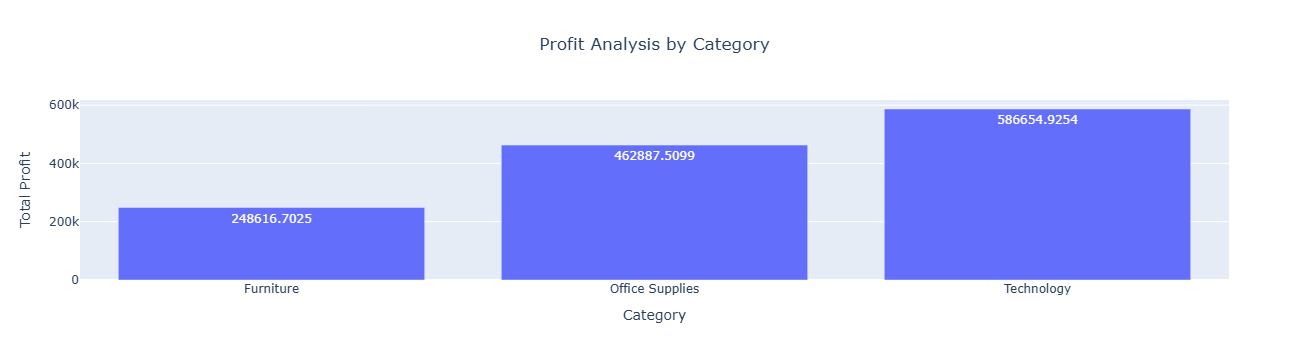

In [40]:
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()
fig = px.bar(profit_by_category, x='Category',
             y='Profit',
             text='Profit',
             title='Profit Analysis by Category')
fig.update_layout(title_text='Profit Analysis by Category', title_x=0.5)

fig.update_layout(xaxis_title='Category', yaxis_title='Total Profit')

fig.show()

Technology category has the highest profit among all three categories.

**Which Year had the highest net Profit?**

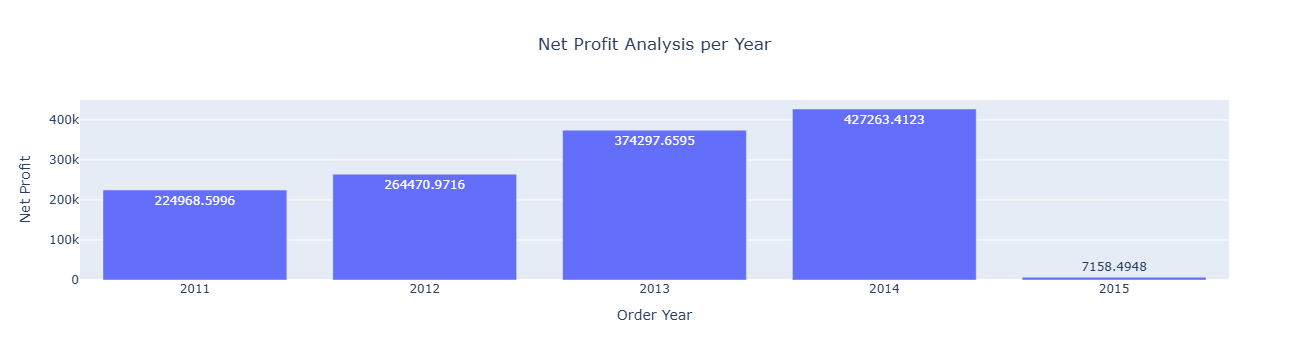

In [41]:
profit_per_year = df.groupby('Order Year')['Profit'].sum().reset_index()
fig = px.bar(profit_per_year, x='Order Year',
             y='Profit',
             text='Profit',
             title='Net Profit Analysis per Year')
fig.update_layout(title_text='Net Profit Analysis per Year', title_x=0.5)

fig.update_layout(xaxis_title='Order Year', yaxis_title='Net Profit')

fig.show()

In year 2014, the net profit was highest

**Which year had the highest profit in categories of products?**

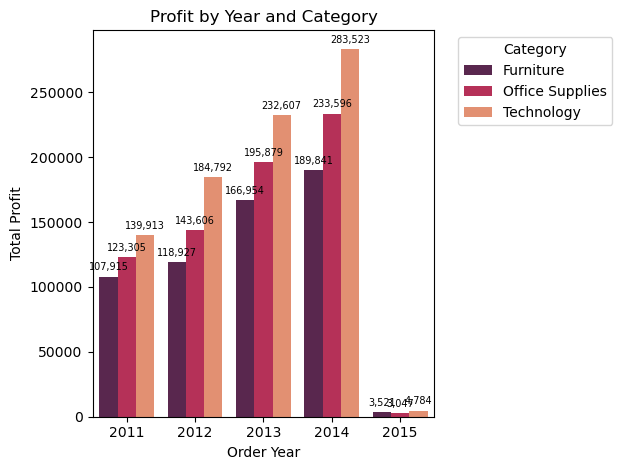

In [46]:
kf = df[df['Profit'] > 0]

profit_per_year = (
    kf.groupby(['Order Year', 'Category'])['Profit']
      .sum()
      .reset_index())

ax = sns.barplot(
    data=profit_per_year,
    x='Order Year',
    y='Profit',
    hue='Category',
    errorbar=None,
    palette='rocket')


for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.annotate(
            f'{height:,.0f}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=7,
            xytext=(0, 3),
            textcoords='offset points')

plt.title('Profit by Year and Category')
plt.xlabel('Order Year')
plt.ylabel('Total Profit')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Which year had the highest loss in categories of products?**

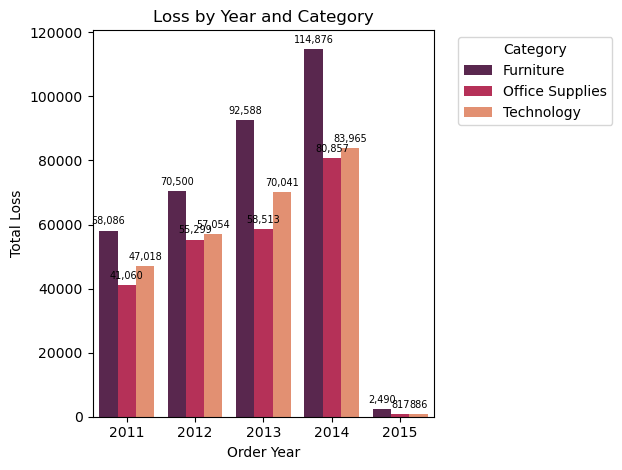

In [48]:
# Filter rows where Profit is negative
lf = df[df['Profit'] < 0].copy()

# Convert negative Profit values into positive Loss values
lf['Loss'] = lf['Profit'] * -1

# Calculate total loss for each year and category
loss_per_year = (
    lf.groupby(['Order Year', 'Category'])['Loss']
      .sum()
      .reset_index())

# Create the bar plot
ax = sns.barplot(
    data=loss_per_year,
    x='Order Year',
    y='Loss',
    hue='Category',
    errorbar=None,
    palette='rocket')

# Add loss values on top of each bar
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            f'{height:,.0f}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=7,
            xytext=(0, 3),
            textcoords='offset points')

# Customize the chart
plt.title('Loss by Year and Category')
plt.xlabel('Order Year')
plt.ylabel('Total Loss')

# Move the legend outside the plot
plt.legend(
    title='Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left')

plt.tight_layout()
plt.show()

**What is the distribution of the time difference (in days) between the order date and ship date ship mode wise for the orders in the dataset?**

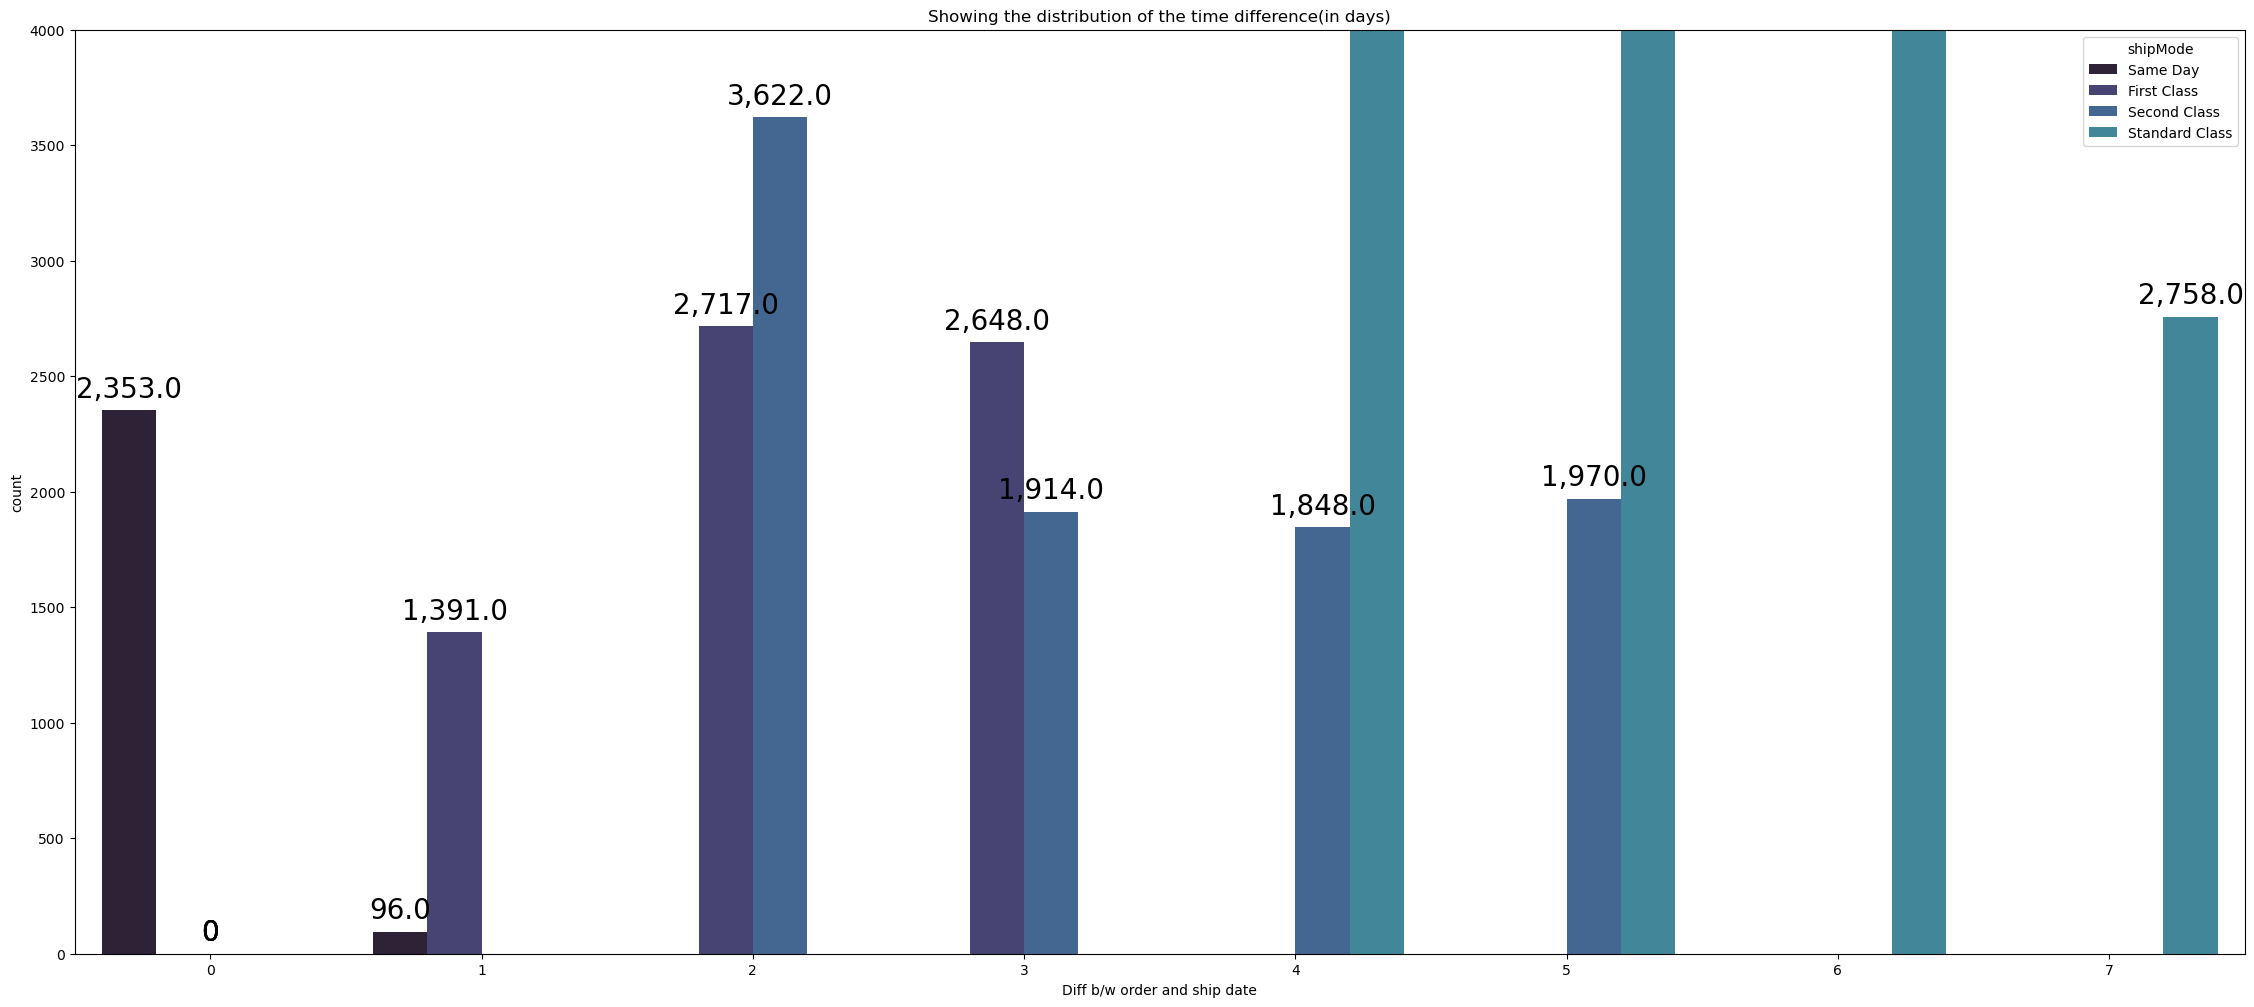

In [50]:
plt.figure(figsize=(28, 12))
sns.set_palette('mako')

ax = sns.countplot(data=df, x='Diff b/w order and ship date', hue='ShipMode')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(format(height, ','),
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=20)

plt.title('Showing the distribution of the time difference(in days)')
plt.ylim(0, 4000)
plt.legend(title='shipMode', bbox_to_anchor=(1, 1))
plt.show()

The Standard class shipping mode took maximum number of days for shipment of the products.

**Which mode of shipping was used the most?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\1560071455.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



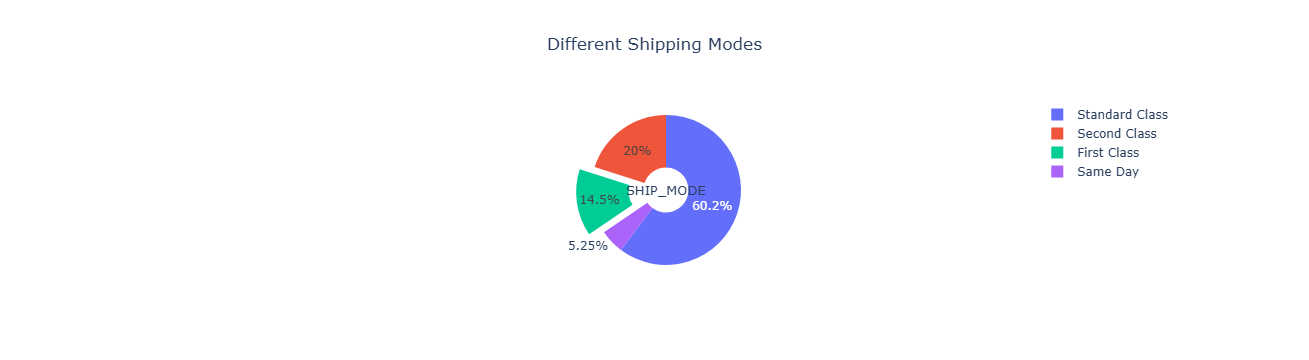

In [51]:
p=df['ShipMode'].value_counts()
labels =  ["Standard Class","Second Class","First Class","Same Day"]
values = [p[0],p[1],p[2],p[3]]

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3,pull=[0, 0, 0.2, 0])])
fig.update_layout(
    title_text="Different Shipping Modes",title_x=0.5,

annotations=[dict(text='SHIP_MODE', x=0.5, y=0.5, font_size=13, showarrow=False)])
fig.show()

Standard class mode has been used the most for shipping of products i.e 60.2% of usage.

**Which segment had the highest number of Orders?**

In [53]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\1707601366.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



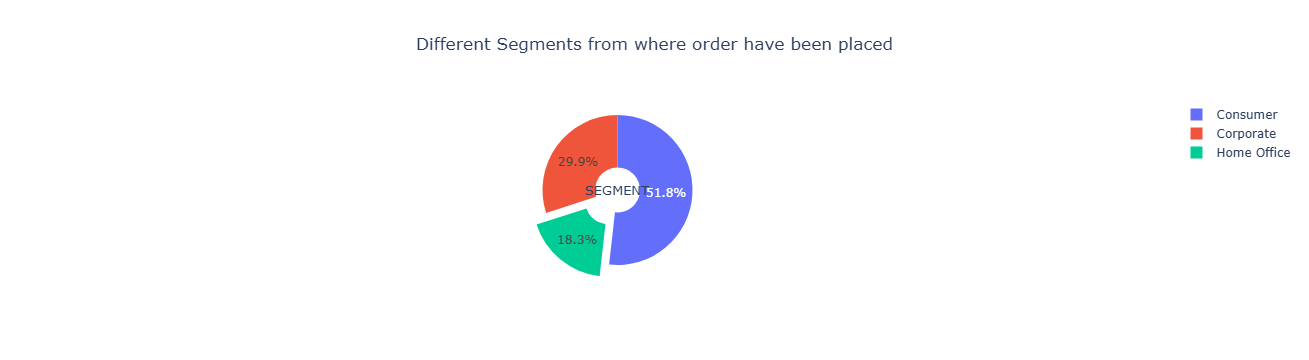

In [56]:
v=df['Segment'].value_counts()
labels =  ["Consumer","Corporate","Home Office"]
values = [v[0],v[1],v[2]]

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3,pull=[0, 0, 0.2])])
fig.update_layout(
    title_text="Different Segments from where order have been placed",title_x=0.5,
    annotations=[dict(text='SEGMENT', x=0.5, y=0.5, font_size=13, showarrow=False)])
fig.show()

Consumer segment had the highest number of order i.e 51.8%

**In which year did the consumer segment have the lowest average sales?**

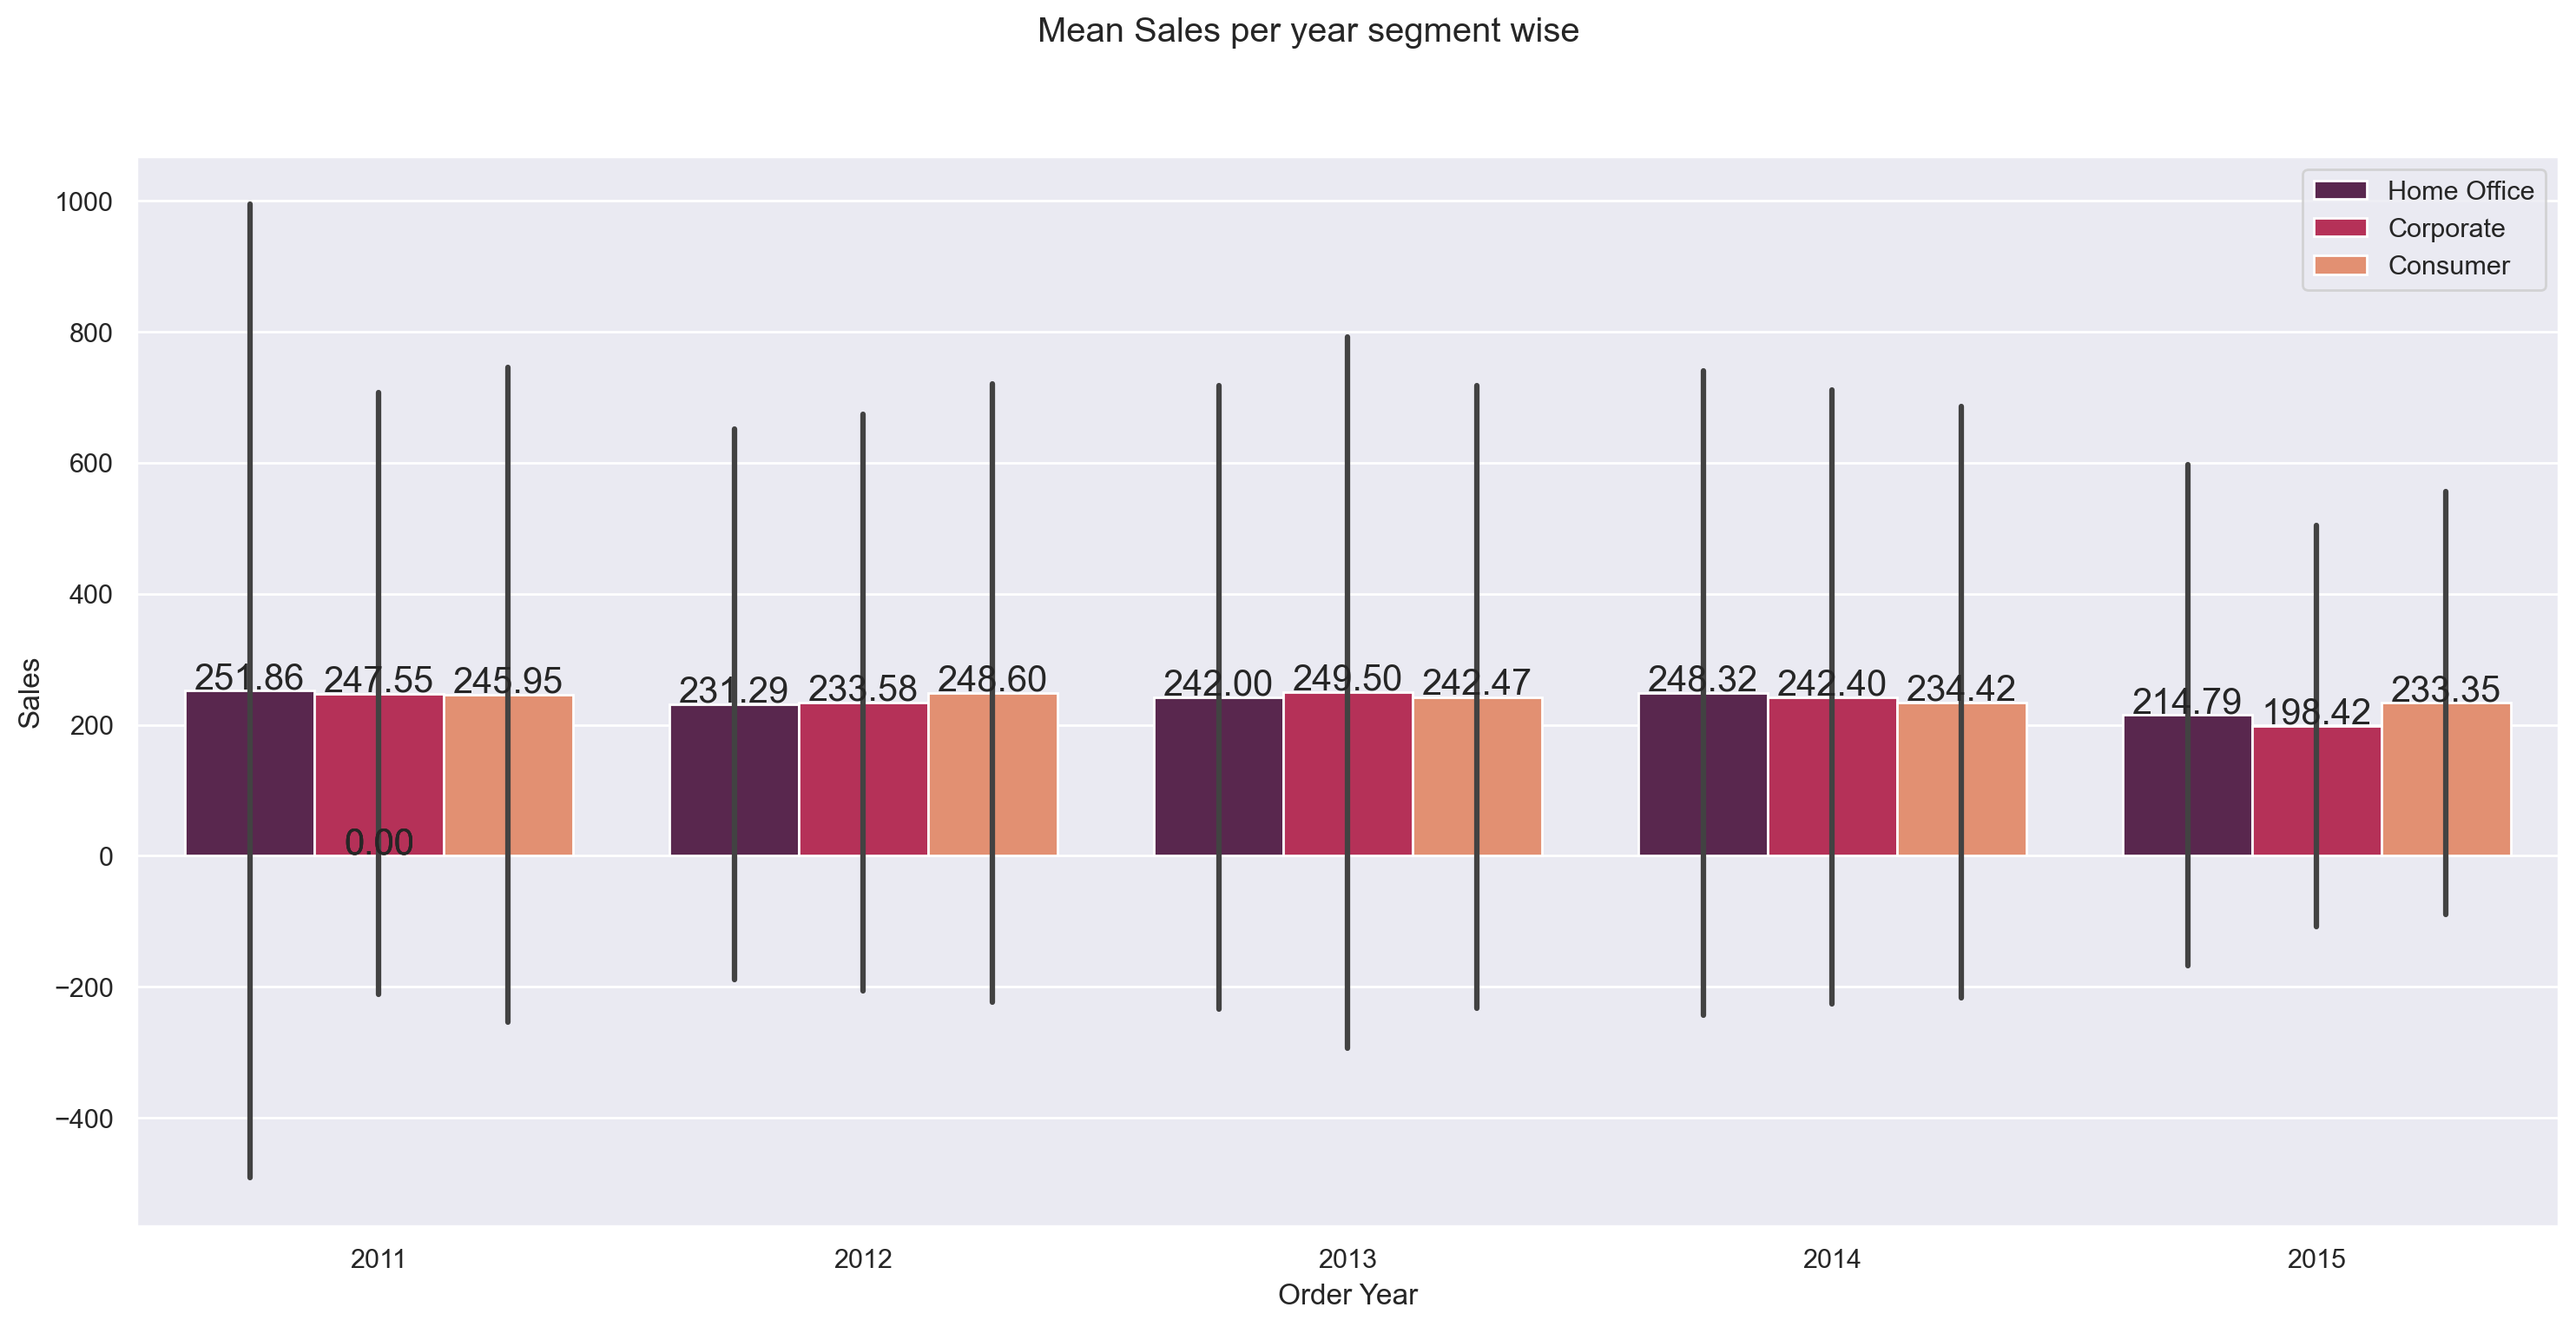

In [57]:
plt.figure(figsize=(18, 8), dpi=200)
sns.set(style='darkgrid')

ax = sns.barplot(x='Order Year', y='Sales', data=df, estimator=np.mean, errorbar='sd', hue='Segment', palette='rocket')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=15)

plt.suptitle('Mean Sales per year segment wise')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In year 2015, consumer segment have the lowest average sales.

**Which category of product have been ordered least by consumer segment?**

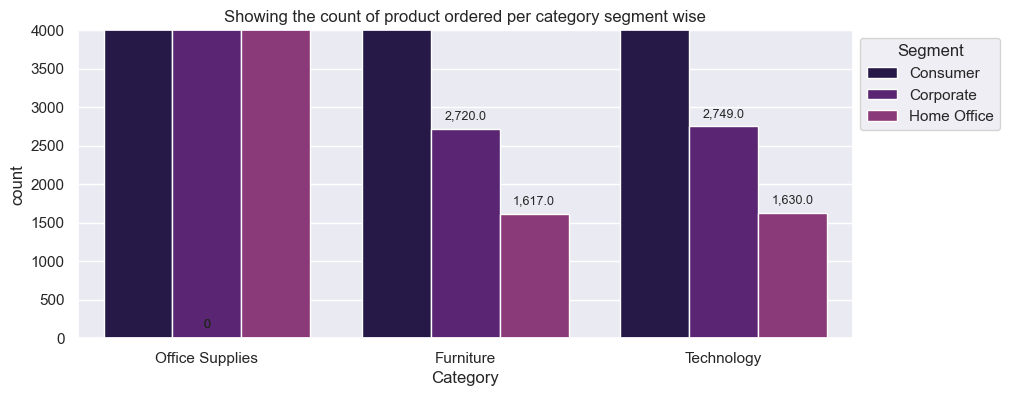

In [58]:
plt.figure(figsize=(10, 4))
sns.set_palette('magma')

ax = sns.countplot(data=df, x='Category', hue='Segment')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(format(height, ','),
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=9)

plt.title('Showing the count of product ordered per category segment wise')
plt.ylim(0, 4000)
plt.legend(title='Segment', bbox_to_anchor=(1, 1))
plt.show()

Furniture Category of product have been ordered least by the consumer segment.

**Which attribute is highly dependent on Sales?**

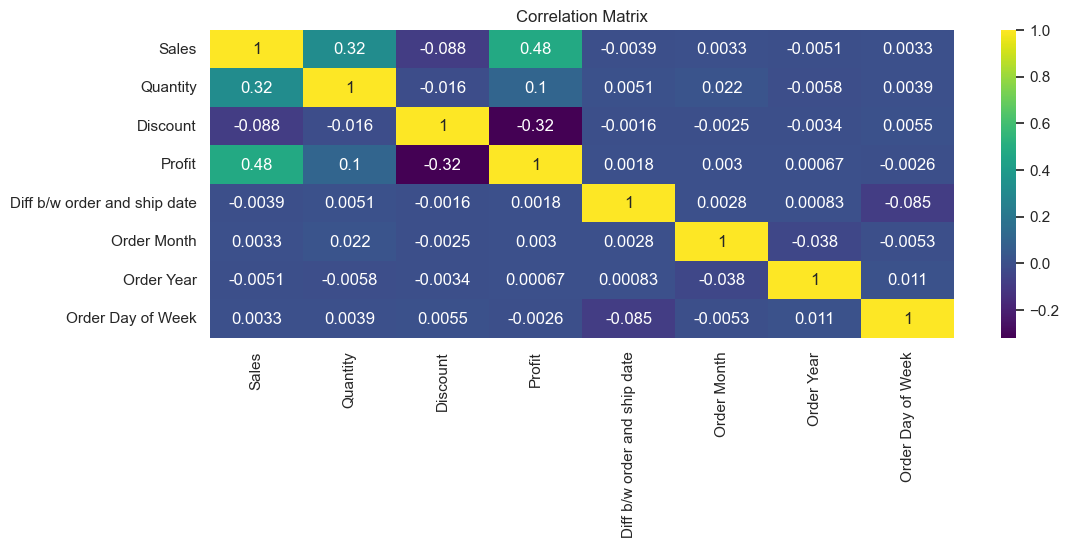

In [62]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Plot the correlation matrix
plt.figure(figsize=(12, 4))
sns.heatmap(
    numeric_df.corr(),
    cmap='viridis',
    annot=True
)

plt.title('Correlation Matrix')
plt.show()

Profit is highly dependent on sales i.e 0.48 in correlation table.

In [63]:
df.columns

Index(['OrderID', 'Sales', 'Quantity', 'Discount', 'City', 'Country', 'Market',
       'Region', 'State', 'OrderPriority', 'Segment', 'Category',
       'SubCategory', 'ProductName', 'ShipMode', 'Profit',
       'Diff b/w order and ship date', 'Order Month', 'Order Year',
       'Order Day of Week'],
      dtype='object')

**Which sub-category of product have been ordered most?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\811013734.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




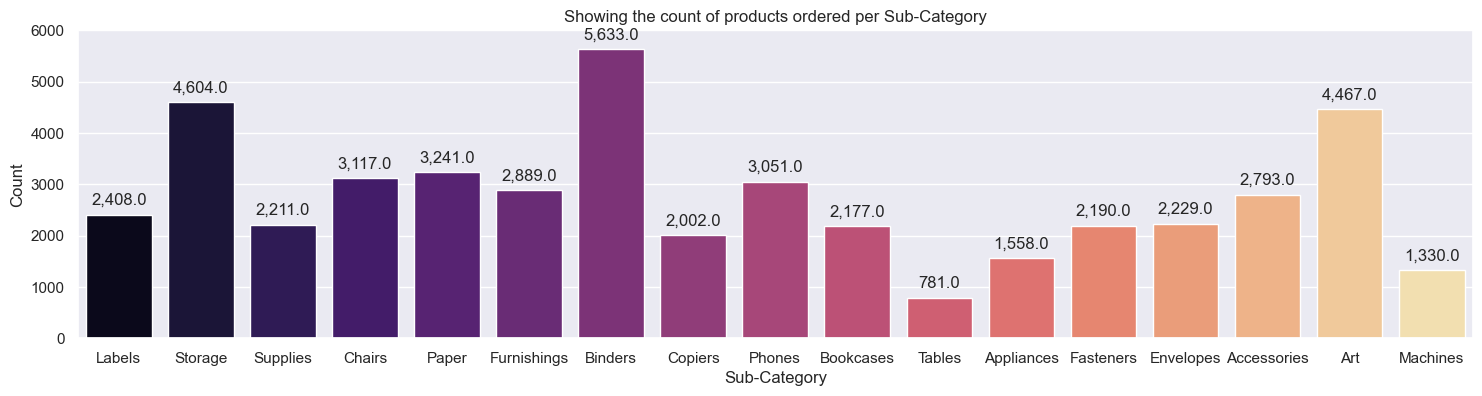

In [69]:
plt.figure(figsize=(18, 4))

ax = sns.countplot(
    data=df,
    x='SubCategory',
    palette='magma')

# Add count values on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        format(height, ','),
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=12)

plt.title('Showing the count of products ordered per Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.ylim(0, 6000)
plt.show()

Binders sub-category of product have been ordered most.

**Which sub-category of product have highest net profit?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\1893878067.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




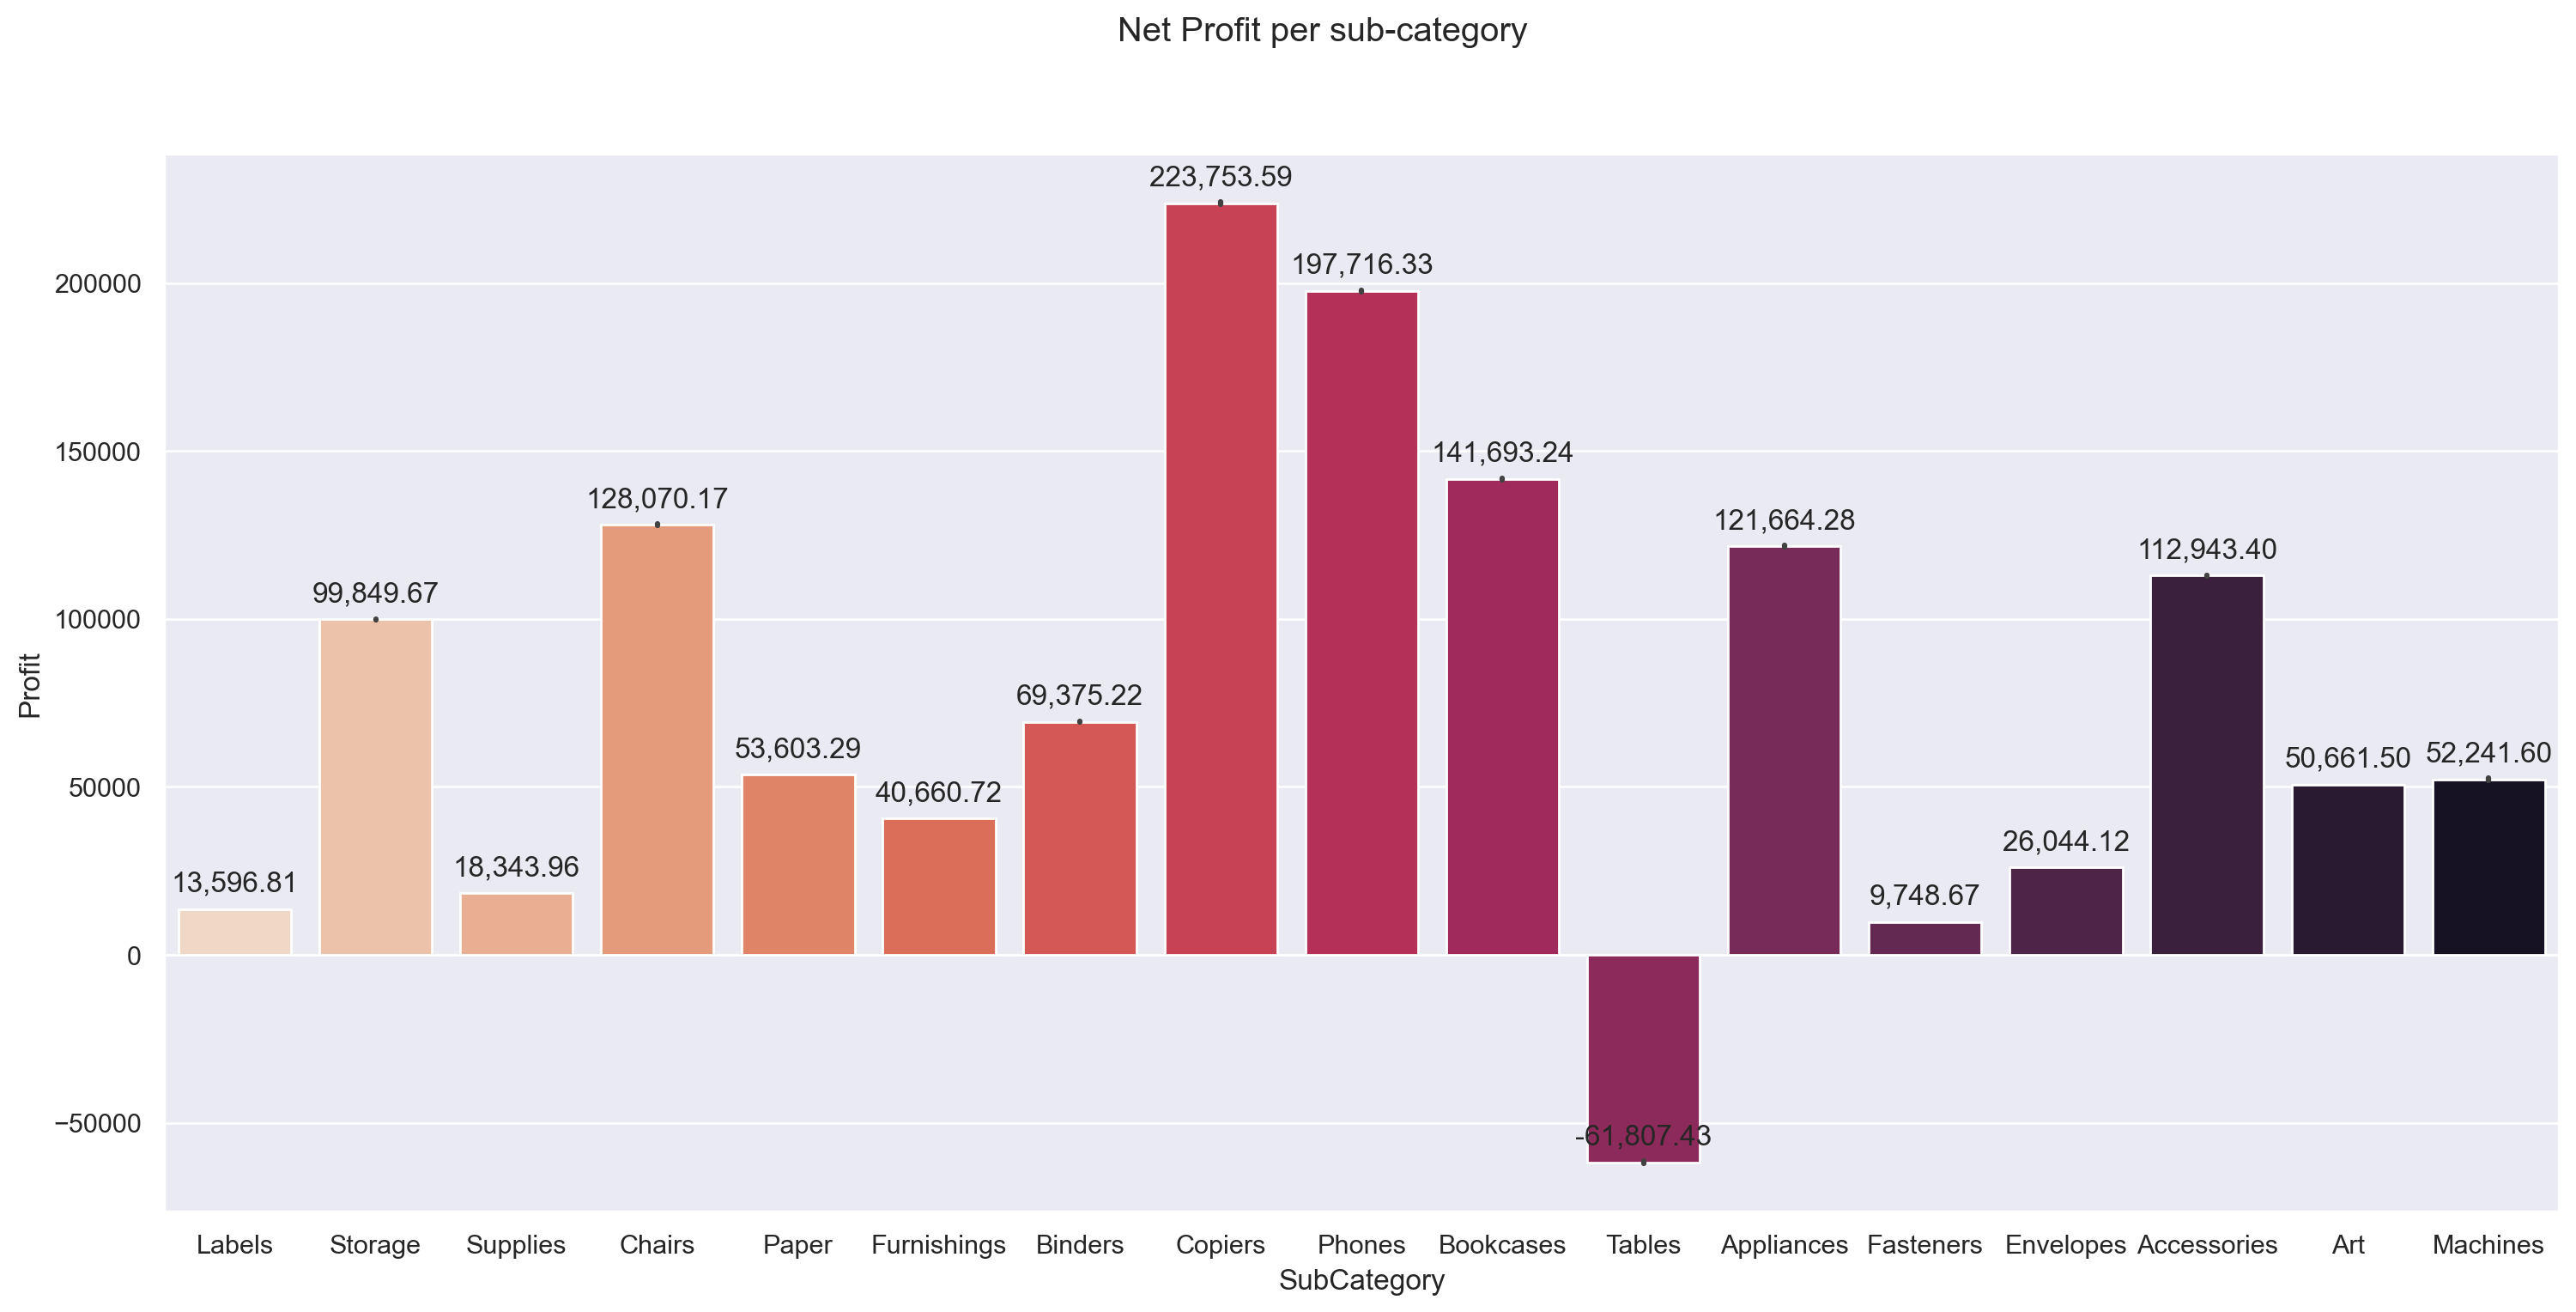

In [70]:
plt.figure(figsize=(18, 8), dpi=200)
sns.set(style='darkgrid')

ax = sns.barplot(x='SubCategory', y='Profit', data=df, estimator=np.sum, errorbar='sd', palette='rocket_r')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(format(height, ',.2f'),
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=12)

plt.suptitle('Net Profit per sub-category')
plt.show()

Copiers sub-category of product have highest net profit.

**In which category of product discount offered is least and profit gained is highest?**

Text(0.5, 1.0, 'Overall Sales VS Profit Discount wise')

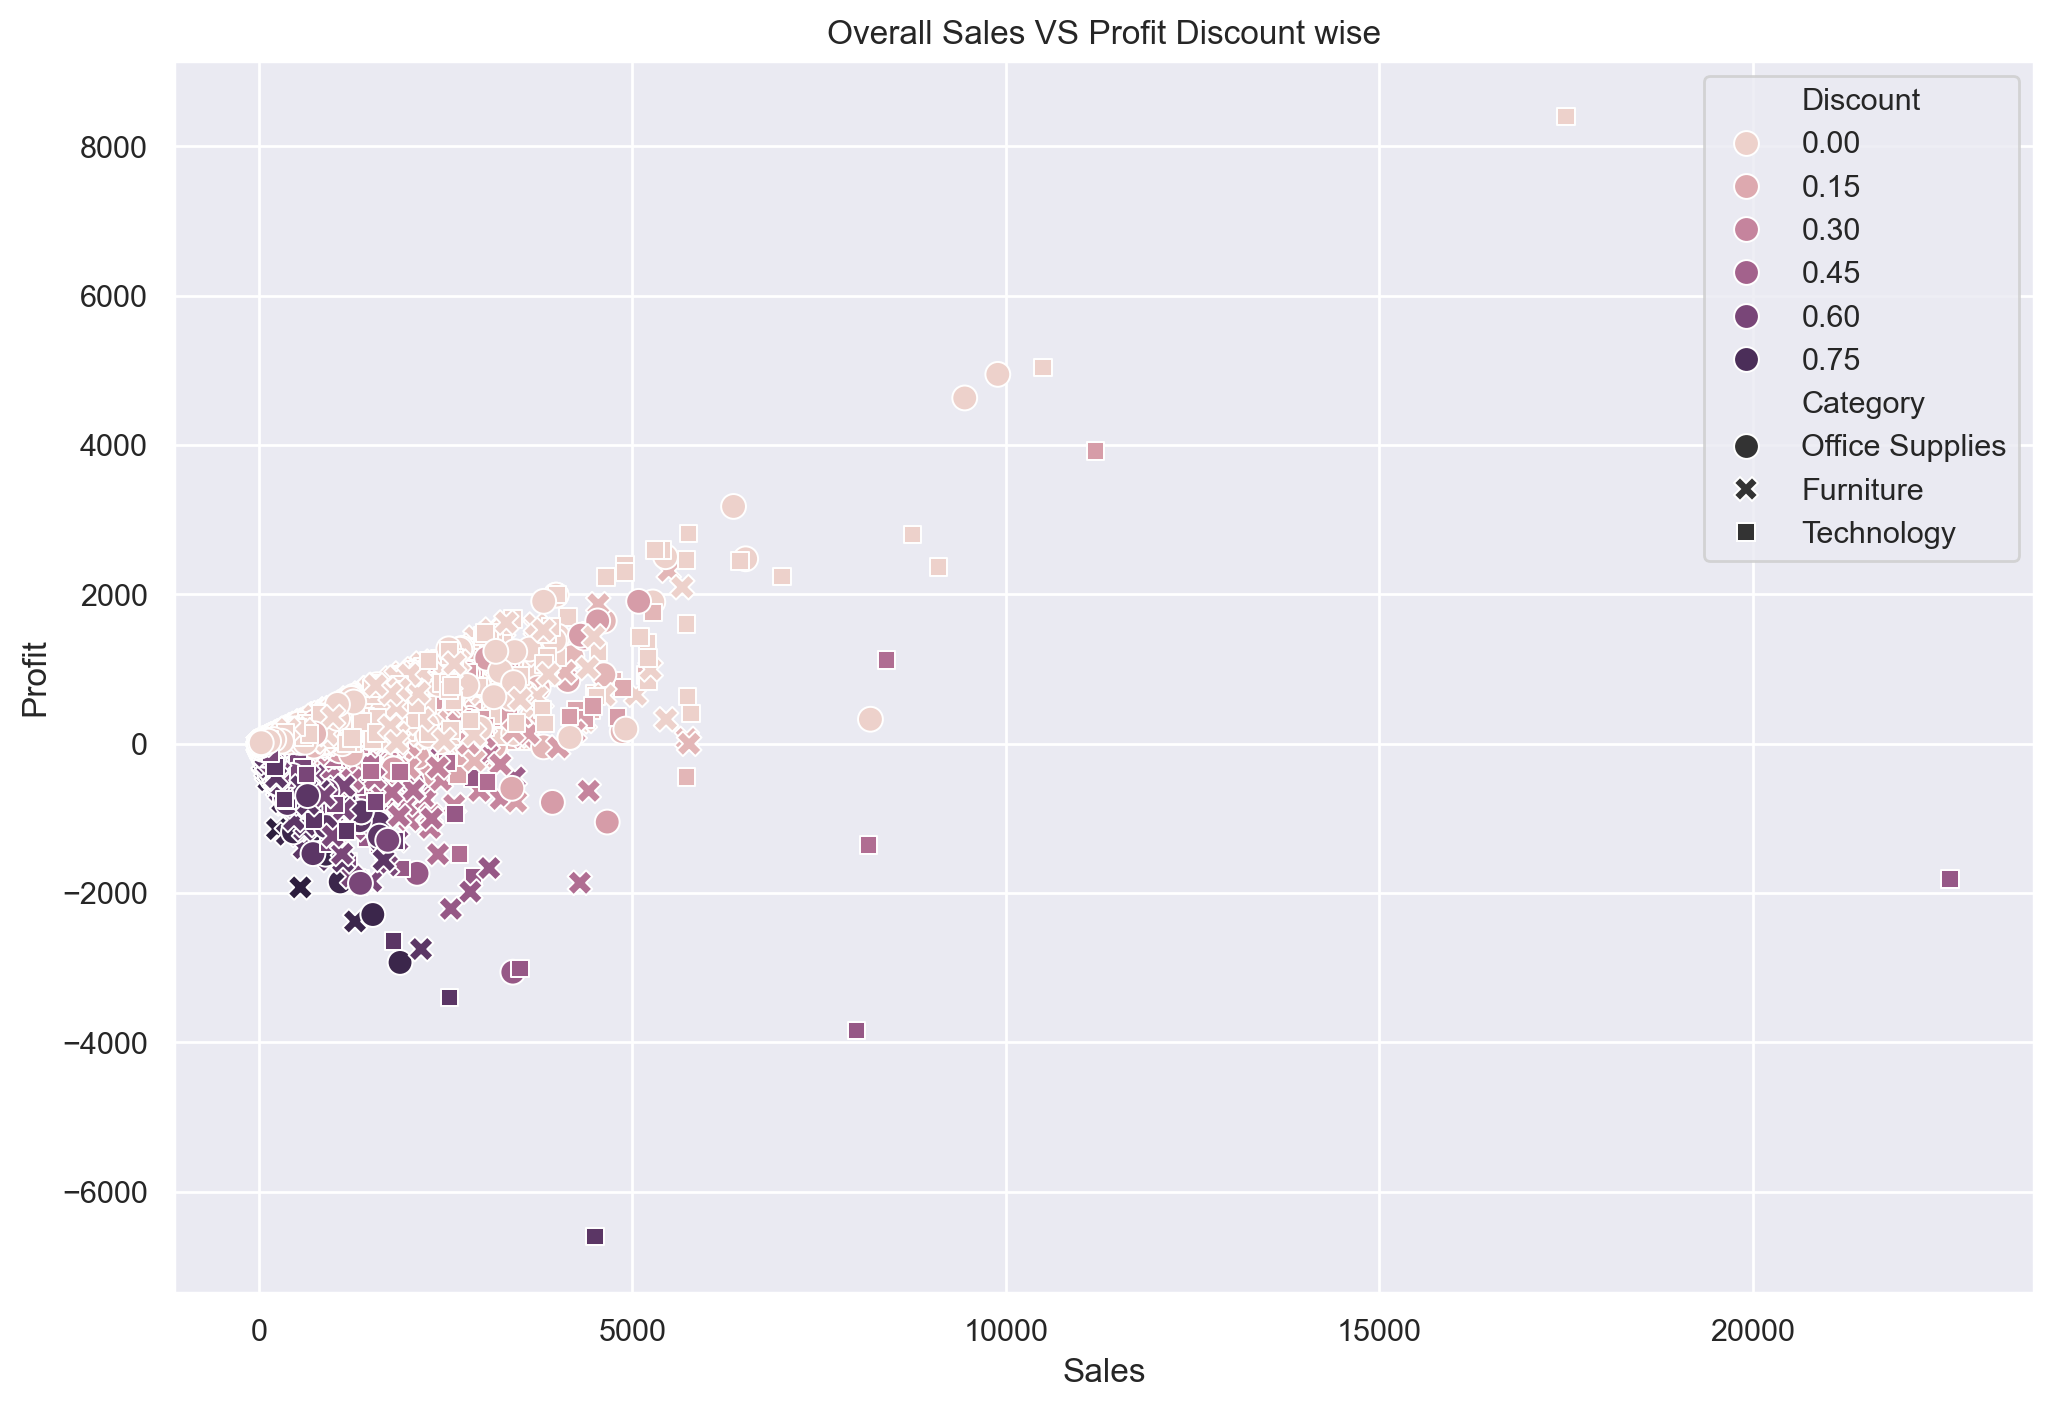

In [71]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Sales',y='Profit',data=df,style='Category',hue='Discount',s=80)
plt.title("Overall Sales VS Profit Discount wise")

In technology category, discount offered is the least and profit gained is the highest.

**Which month had the highest sales?**

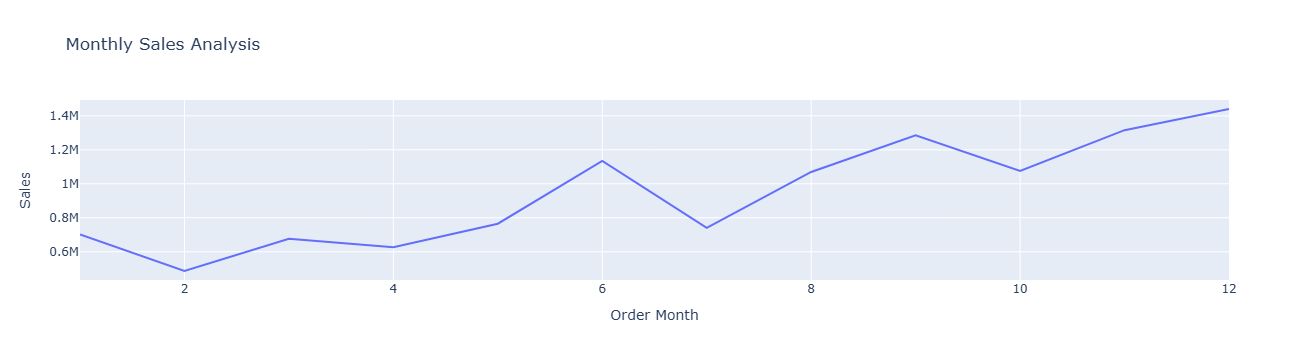

In [72]:
sales_by_month = df.groupby(['Order Month'])['Sales'].sum().reset_index()
fig = px.line(sales_by_month, x='Order Month', y='Sales', title='Monthly Sales Analysis')
fig.show()

In December month, sales was highest.

**Which month had the highest profit?**

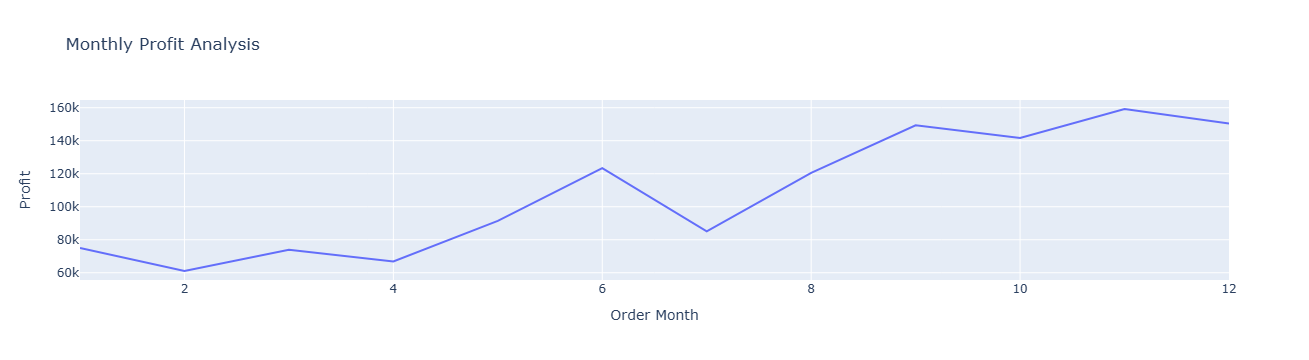

In [74]:
sales_by_month = df.groupby(['Order Month'])['Profit'].sum().reset_index()
fig = px.line(sales_by_month, x='Order Month', y='Profit', title='Monthly Profit Analysis')
fig.show()

In November month, Profit was highest.

**Which state contributed most towards sales?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\1559061597.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\C1\AppData\Local\Temp\ipykernel_8812\1559061597.py:24: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



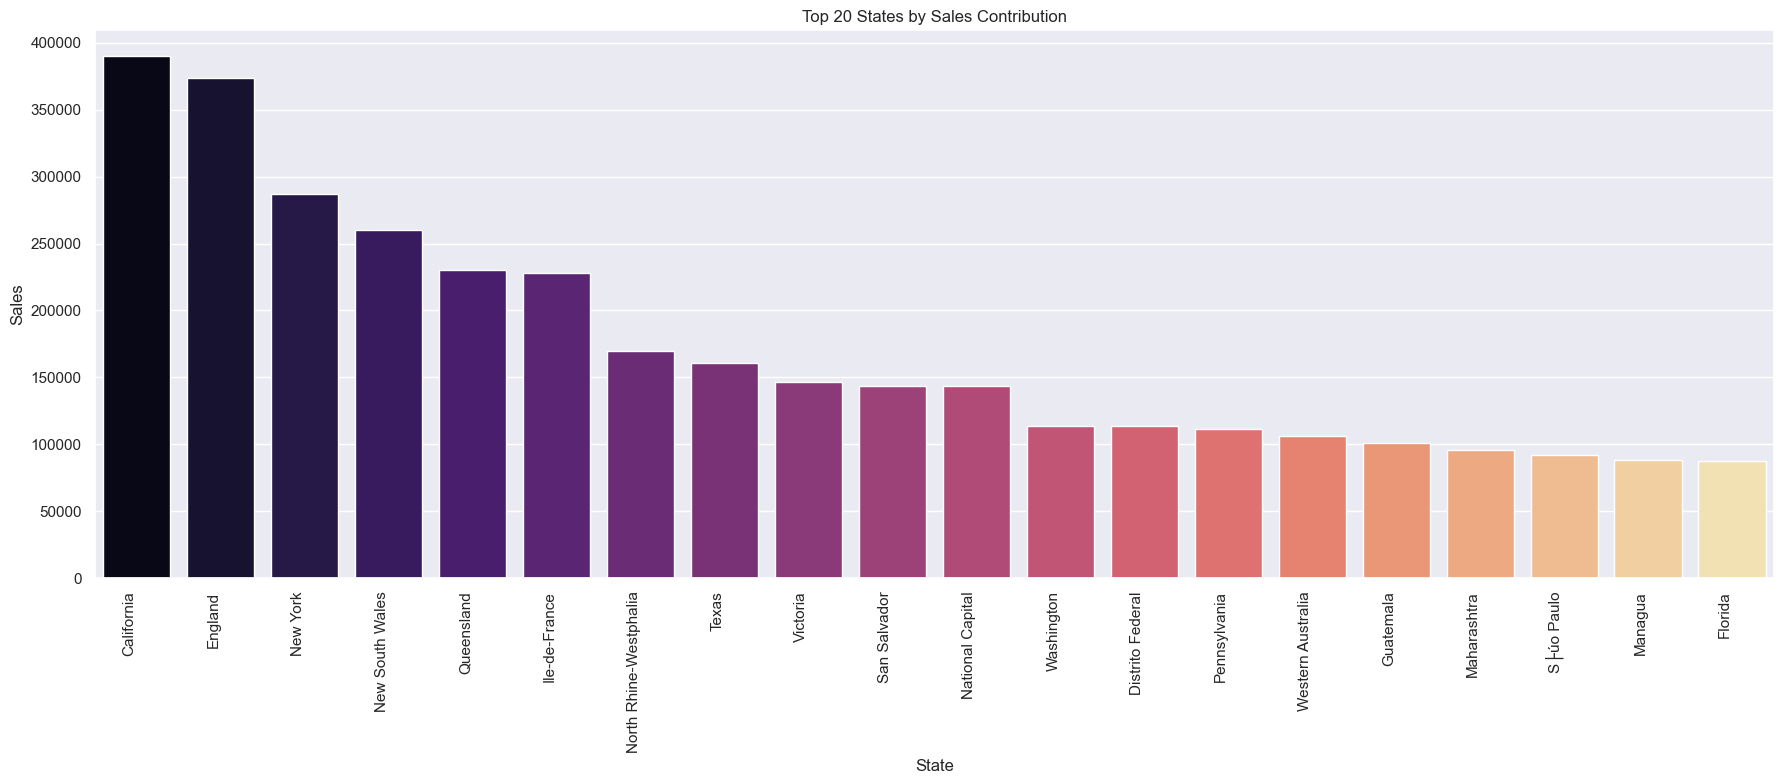

In [84]:
# Calculate total sales for each state and sort them in descending order
order_by_state = (
    df.groupby('State')['Sales']
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
      .head(20))

# Set the figure size before creating the plot
width = 18
height = 8

sns.set(rc={'figure.figsize': (width, height)})
sns.set(font_scale=1)

# Create the bar plot
chart = sns.barplot(
    data=order_by_state,
    x='State',
    y='Sales',
    palette='magma')

# Rotate x-axis labels
chart.set_xticklabels(
    chart.get_xticklabels(),
    rotation=90,
    horizontalalignment='right')

# Set the chart title
chart.set(title='Top 20 States by Sales Contribution')

plt.tight_layout()
plt.show()

**Which region contributed most towards sales?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\3934345229.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\C1\AppData\Local\Temp\ipykernel_8812\3934345229.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



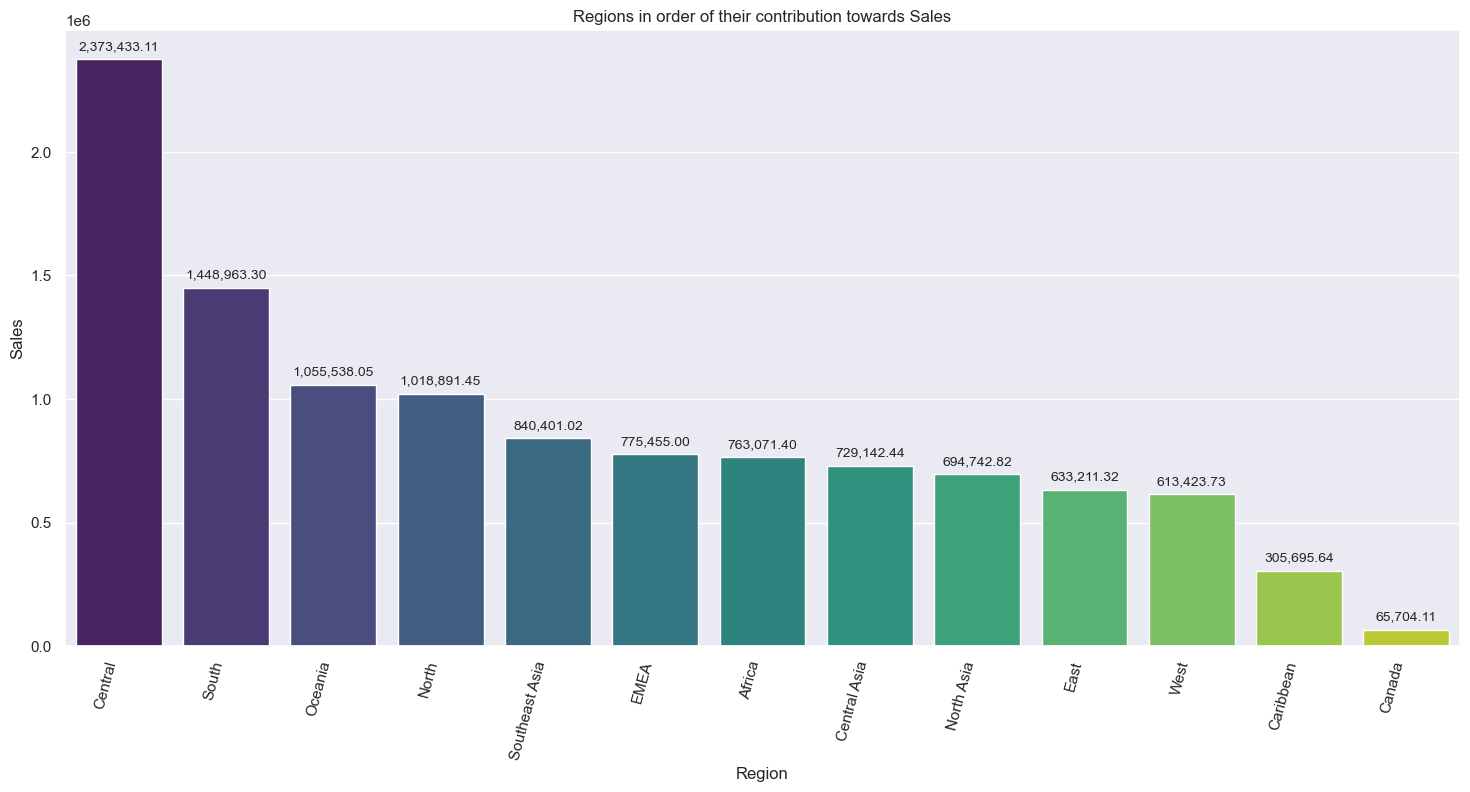

In [90]:
order_by_region = df.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)
chart = sns.barplot(data=order_by_region,x='Region',y='Sales',palette='viridis')

for p in chart.patches:
    height = p.get_height()
    chart.annotate(format(height, ',.2f'),
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom', xytext=(0, 5),
                   textcoords='offset points', fontsize=10)

chart.set_xticklabels(chart.get_xticklabels(), rotation=75,horizontalalignment='right')
chart.set(title='Regions in order of their contribution towards Sales')
None

**Which Market had the highest sales?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\4291989963.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\C1\AppData\Local\Temp\ipykernel_8812\4291989963.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



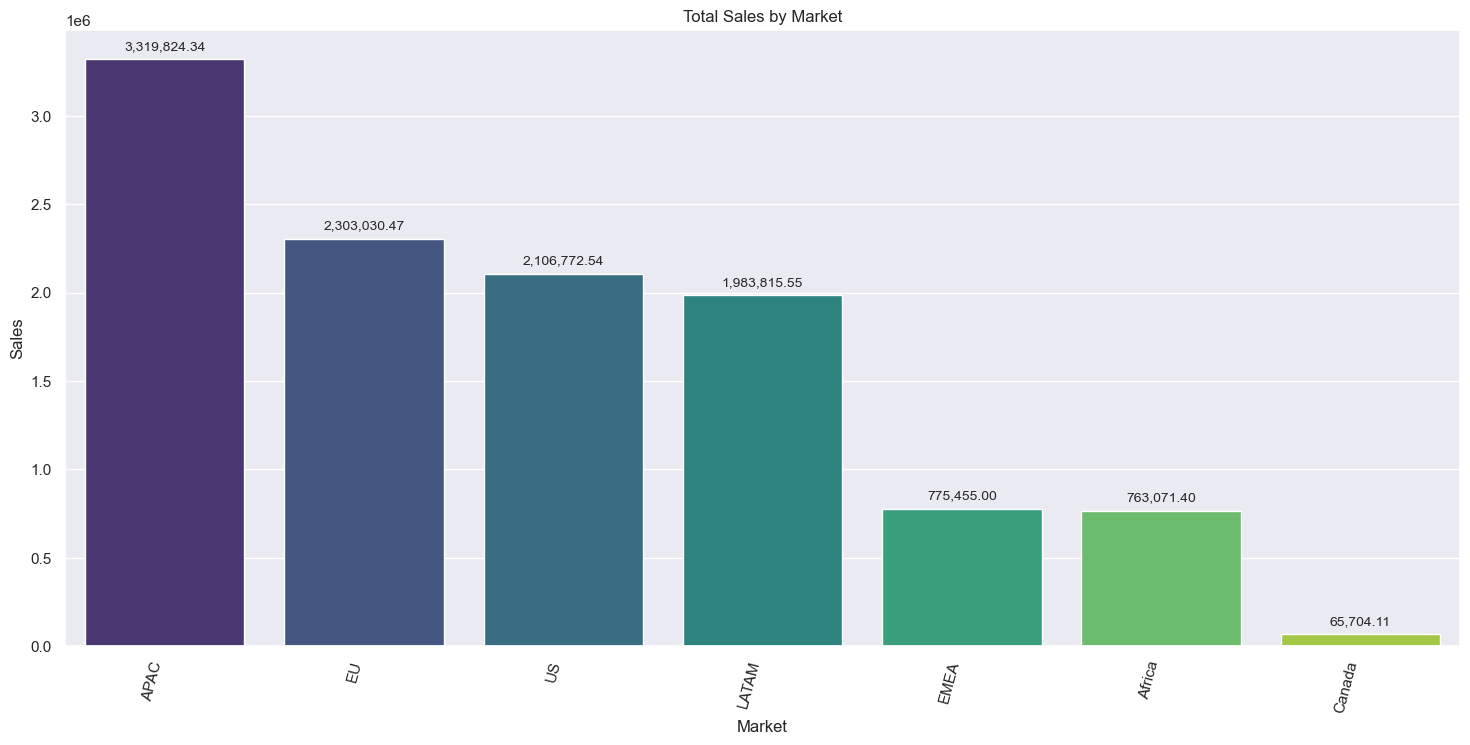

In [110]:
order_by_Market = df.groupby('Market')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)
chart = sns.barplot(data=order_by_Market,x='Market',y='Sales',palette='viridis')

for p in chart.patches:
    height = p.get_height()
    chart.annotate(format(height, ',.2f'),
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom', xytext=(0, 5),
                   textcoords='offset points', fontsize=10)

chart.set_xticklabels(chart.get_xticklabels(), rotation=75,horizontalalignment='right')
chart.set(title='Total Sales by Market')
None

**Which Priority had the highest sales?**

C:\Users\C1\AppData\Local\Temp\ipykernel_8812\2990690162.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\C1\AppData\Local\Temp\ipykernel_8812\2990690162.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



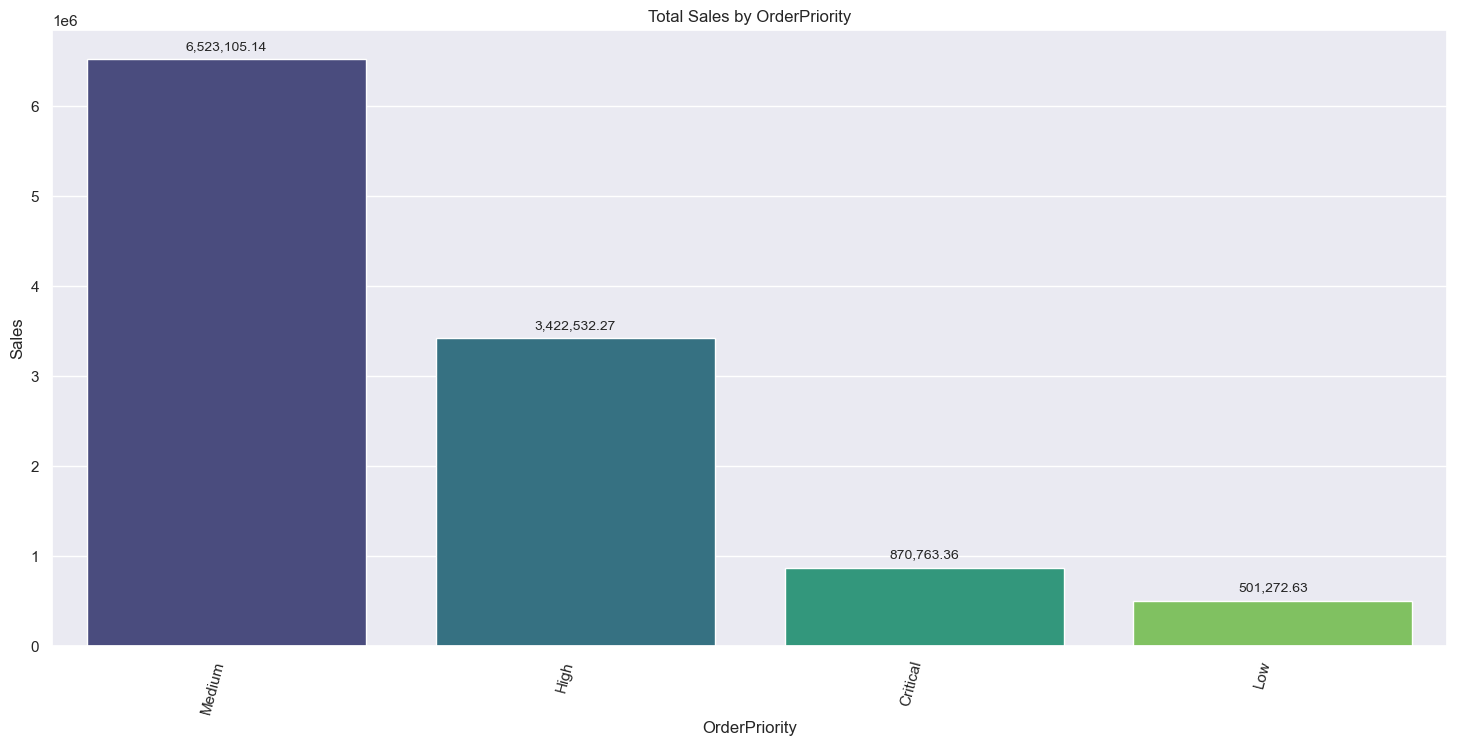

In [111]:
order_by_priority = df.groupby('OrderPriority')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)
chart = sns.barplot(data=order_by_priority,x='OrderPriority',y='Sales',palette='viridis')

for p in chart.patches:
    height = p.get_height()
    chart.annotate(format(height, ',.2f'),
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom', xytext=(0, 5),
                   textcoords='offset points', fontsize=10)

chart.set_xticklabels(chart.get_xticklabels(), rotation=75,horizontalalignment='right')
chart.set(title='Total Sales by OrderPriority')
None